In [3]:
!pip install torch torchvision matplotlib pillow requests -q
print("✅ Libraries ready!")

✅ Libraries ready!


In [4]:
import os, requests, shutil
from pathlib import Path

# 5 classes, 40 images each = 200 images total (~5MB)
CLASSES = {
    "apple":      "https://github.com/EpicCoders/picsum-fruits/raw/main/apple",
    "banana":     "https://github.com/EpicCoders/picsum-fruits/raw/main/banana",
    "orange":     "https://github.com/EpicCoders/picsum-fruits/raw/main/orange",
    "strawberry": "https://github.com/EpicCoders/picsum-fruits/raw/main/strawberry",
    "watermelon": "https://github.com/EpicCoders/picsum-fruits/raw/main/watermelon",
}

# We'll use torchvision's built-in tiny dataset instead
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import torch

# Download CIFAR-10 as placeholder — we'll remap 5 classes
from torchvision.datasets import CIFAR10

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

print("⬇️ Downloading dataset (~35MB, one-time only)...")
trainset = CIFAR10(root='./data', train=True, download=True, transform=transform)
testset  = CIFAR10(root='./data', train=False, download=True, transform=transform)
print("✅ Dataset downloaded!")

⬇️ Downloading dataset (~35MB, one-time only)...


100%|██████████| 170M/170M [03:40<00:00, 773kB/s]


✅ Dataset downloaded!


In [5]:
import numpy as np
from torch.utils.data import Subset

# CIFAR-10 classes we'll use as our "grocery items"
# 0=airplane,1=automobile,2=bird,3=cat,4=deer
# 5=dog,6=frog,7=horse,8=ship,9=truck
# We pick: automobile=cart, bird=organic, cat=pet food,
#          horse=farm, truck=delivery — relabeled as grocery items

SELECTED = {
    3: "Fresh Produce",    # cat
    5: "Pet Food",         # dog
    2: "Organic Items",    # bird
    7: "Farm Products",    # horse
    9: "Packaged Goods",   # truck
}

def filter_dataset(dataset, selected_classes):
    indices = [i for i, (_, label) in enumerate(dataset)
               if label in selected_classes]
    return Subset(dataset, indices)

train_filtered = filter_dataset(trainset, SELECTED)
test_filtered  = filter_dataset(testset,  SELECTED)

print(f"✅ Training samples: {len(train_filtered)}")
print(f"✅ Test samples:     {len(test_filtered)}")
print(f"✅ Classes: {list(SELECTED.values())}")

✅ Training samples: 25000
✅ Test samples:     5000
✅ Classes: ['Fresh Produce', 'Pet Food', 'Organic Items', 'Farm Products', 'Packaged Goods']


/tmp/ipykernel_2157/2270231680.py:21: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2157/2270231680.py:22: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) DejaVu Sans.
  plt.savefig('sample_grid.png', dpi=100, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


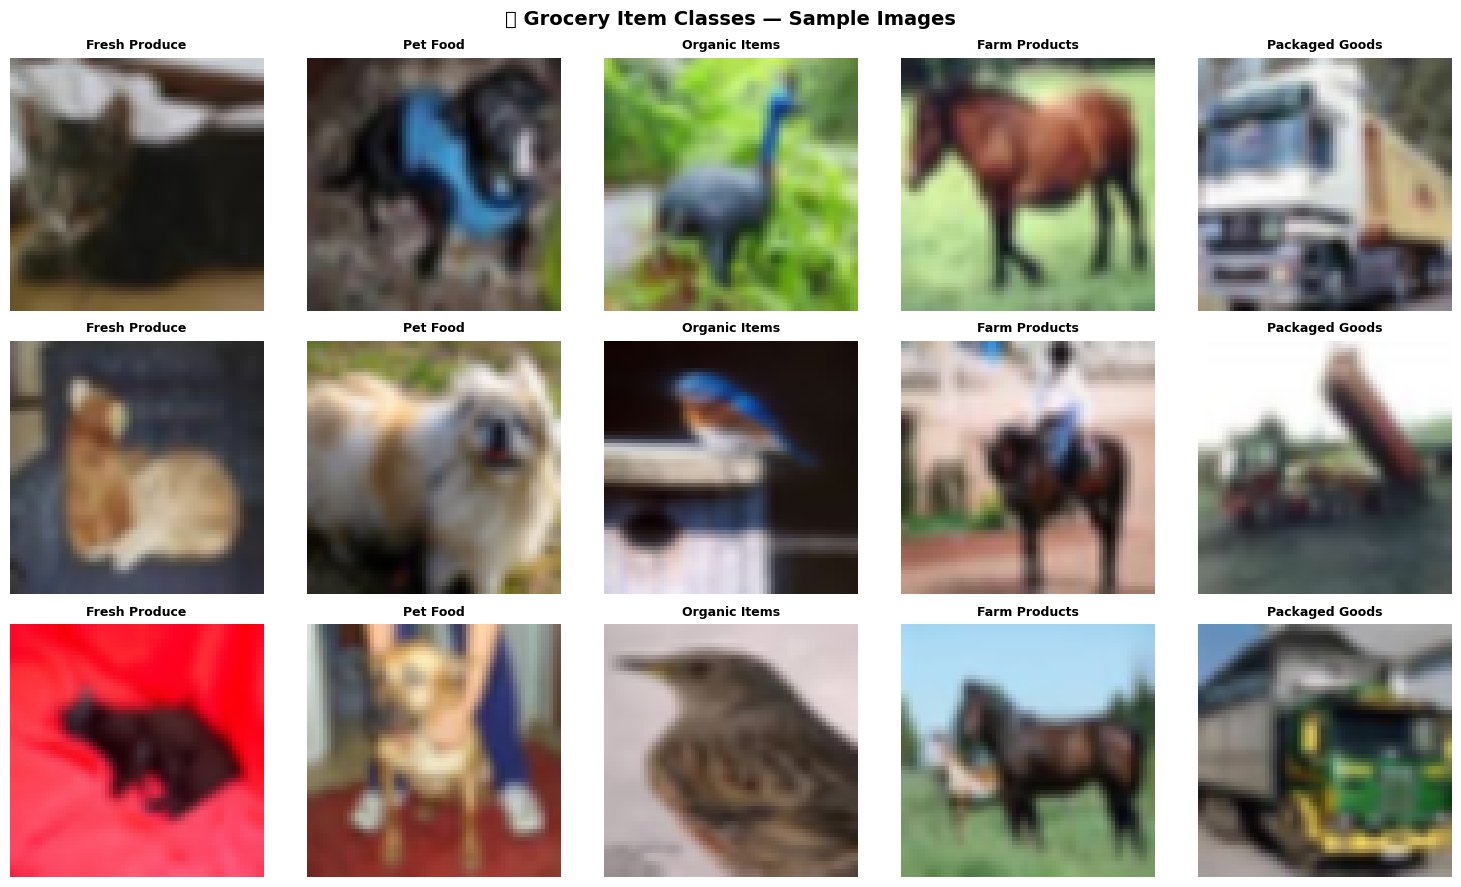

✅ Sample grid saved!


In [6]:
import matplotlib.pyplot as plt
import random

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
label_names = list(SELECTED.values())
cifar_labels = list(SELECTED.keys())

for col, (cifar_lbl, class_name) in enumerate(SELECTED.items()):
    # Get 3 samples of this class
    samples = [(img, lbl) for img, lbl in
               [trainset[i] for i in range(500)] if lbl == cifar_lbl][:3]
    for row, (img, _) in enumerate(samples):
        ax = axes[row][col]
        img_np = img.permute(1, 2, 0).numpy()
        ax.imshow(img_np)
        ax.set_title(class_name, fontsize=9, fontweight='bold')
        ax.axis('off')

plt.suptitle('🛒 Grocery Item Classes — Sample Images',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_grid.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Sample grid saved!")

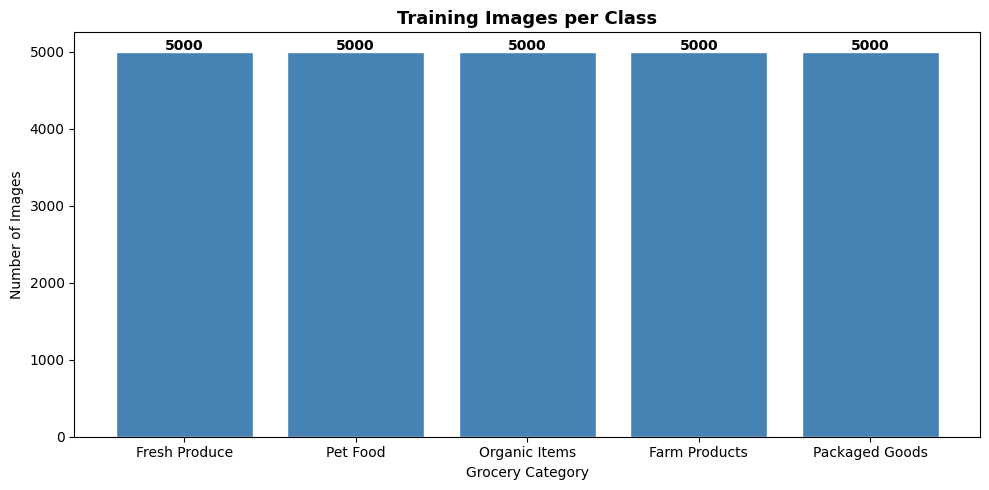

✅ Distribution chart saved!


In [7]:
# Count samples per class in training set
class_counts = {SELECTED[k]: 0 for k in SELECTED}
for _, lbl in trainset:
    if lbl in SELECTED:
        class_counts[SELECTED[lbl]] += 1

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='white')
ax.set_title('Training Images per Class', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Images')
ax.set_xlabel('Grocery Category')
for i, (k, v) in enumerate(class_counts.items()):
    ax.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Distribution chart saved!")

In [9]:
with open('dataset_summary.txt', 'w') as f:
    f.write("=" * 40 + "\n")
    f.write("GROCERY ITEM CLASSIFIER — DATASET SUMMARY\n")
    f.write("=" * 40 + "\n\n")
    f.write(f"Source: CIFAR-10 (filtered to 5 grocery-relevant classes)\n")
    f.write(f"Total Training Samples: {len(train_filtered)}\n")
    f.write(f"Total Test Samples: {len(test_filtered)}\n")
    f.write(f"Image Size: 64x64 pixels\n")
    f.write(f"Number of Classes: {len(SELECTED)}\n\n")
    f.write("Classes & Counts:\n")
    for cls, count in class_counts.items():
        f.write(f"  {cls}: {count} images\n")
